# LSTM Autoencoder with SWaT 2020

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
clean_folder = Path("SWaT.A7_June2020_clean")
file_paths = sorted(clean_folder.glob("*.csv"))

print("Archivos encontrados:", len(file_paths))
for fp in file_paths:
    print(fp)

Archivos encontrados: 4
SWaT.A7_June2020_clean\22June2020_1.csv
SWaT.A7_June2020_clean\22June2020_2.csv
SWaT.A7_June2020_clean\29June2020_1.csv
SWaT.A7_June2020_clean\29June2020_2.csv


In [3]:
def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14400, 61)
22June2020_2 (3600, 61)
29June2020_1 (7201, 61)
29June2020_2 (7201, 61)


In [4]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
print(f"Número de columnas comunes: {len(common_cols)}")

for name, df in files.items():
    extra = sorted(set(df.columns) - set(common_cols))
    if extra:
        print(f"{name} tiene columnas no comunes: {extra}")

Número de columnas comunes: 61


In [5]:
files = {name: df[common_cols].copy() for name, df in files.items()}

base_columns = next(iter(files.values())).columns.tolist()

for name, df in files.items():
    assert df.columns.tolist() == base_columns, f"Columnas distintas en {name}"

print("Todos los archivos tienen las mismas columnas.")

Todos los archivos tienen las mismas columnas.


## Identificación de variables

In [6]:
sample_df = next(iter(files.values()))
all_cols = sample_df.columns.tolist()

timestamp_cols = [c for c in all_cols if c == "t_stamp"]
pv_cols = [c for c in all_cols if c.endswith(".Pv")]
status_cols = [c for c in all_cols if c.endswith(".Status")]
state_cols = [c for c in all_cols if c.startswith("P") and c.endswith("_STATE")]

feature_cols = pv_cols + status_cols + state_cols
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

classified_cols = set(timestamp_cols + feature_cols)
other_cols = [c for c in all_cols if c not in classified_cols]

print("Resumen de variables detectadas")
print(f"Timestamp: {len(timestamp_cols)}")
print(f"Sensores continuos (.Pv): {len(pv_cols)}")
print(f"Actuadores discretos (.Status): {len(status_cols)}")
print(f"Estados discretos (_STATE): {len(state_cols)}")
print(f"Otras columnas no clasificadas: {len(other_cols)}")

Resumen de variables detectadas
Timestamp: 1
Sensores continuos (.Pv): 25
Actuadores discretos (.Status): 29
Estados discretos (_STATE): 6
Otras columnas no clasificadas: 0


In [7]:
summary_rows = []

for name, df in files.items():
    summary_rows.append({
        "file": name,
        "rows": len(df),
        "cols": len(df.columns),
        "start_time": df["t_stamp"].min(),
        "end_time": df["t_stamp"].max(),
        "missing_total": df.isna().sum().sum()
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,file,rows,cols,start_time,end_time,missing_total
0,22June2020_1,14400,61,2020-06-22 10:00:00,2020-06-22 14:01:10.990,0
1,22June2020_2,3600,61,2020-06-22 09:00:00,2020-06-22 09:59:59.000,0
2,29June2020_1,7201,61,2020-06-29 10:00:00,2020-06-29 12:00:00.000,0
3,29June2020_2,7201,61,2020-06-29 13:30:00,2020-06-29 15:30:00.000,60


## Visualización de sensores clave

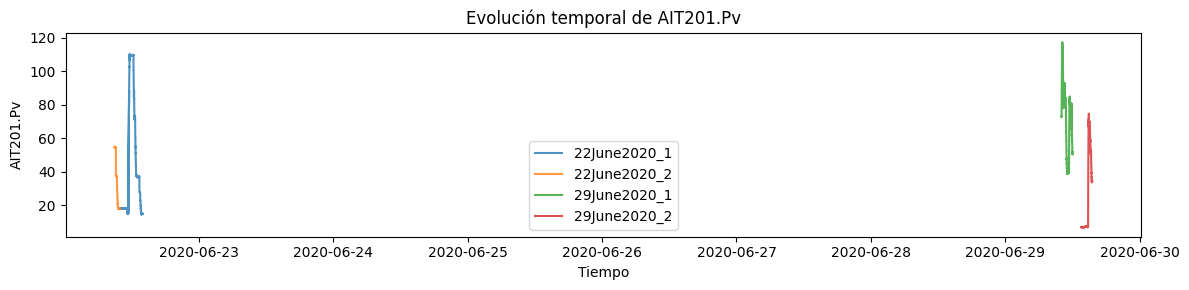

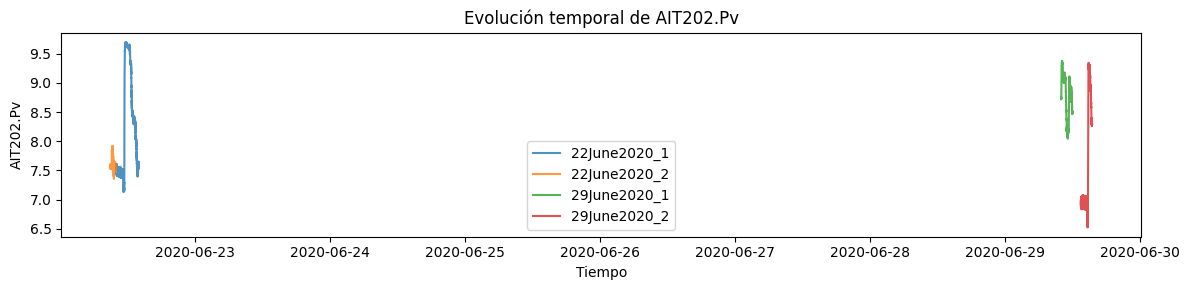

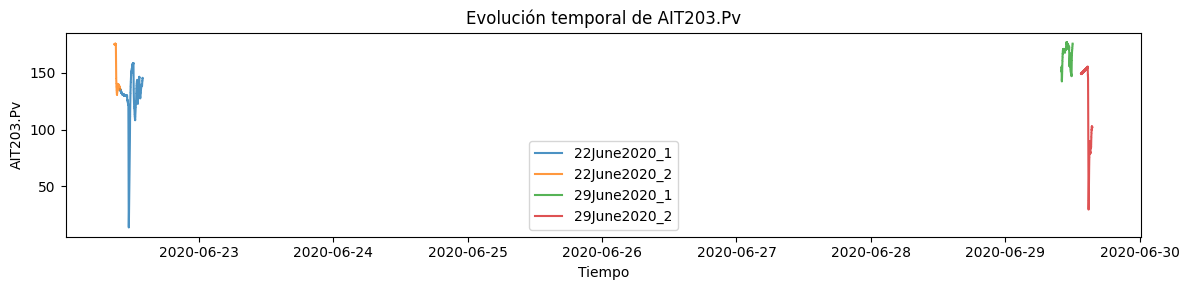

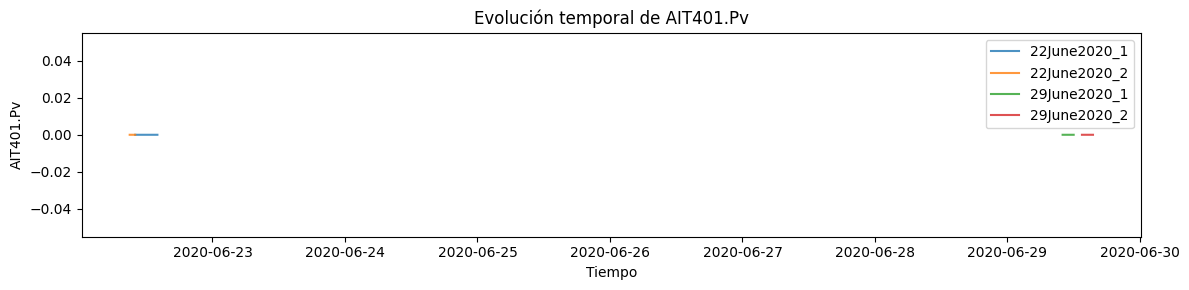

In [8]:
example_pv = ["AIT201.Pv", "AIT202.Pv", "AIT203.Pv", "AIT401.Pv"]

for col in example_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files.items():
        plt.plot(df["t_stamp"], df[col], label=name, alpha=0.8)
    plt.title(f"Evolución temporal de {col}")
    plt.xlabel("Tiempo")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

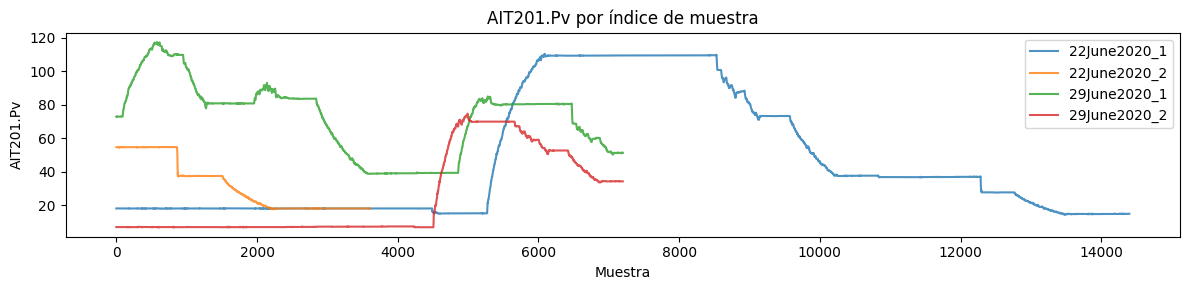

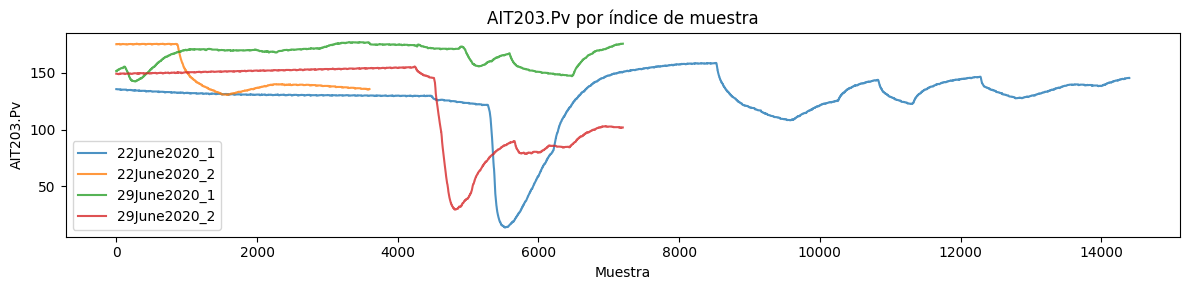

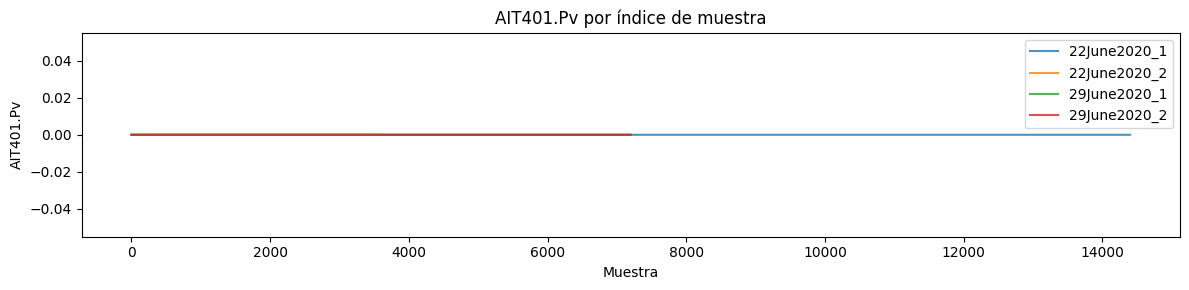

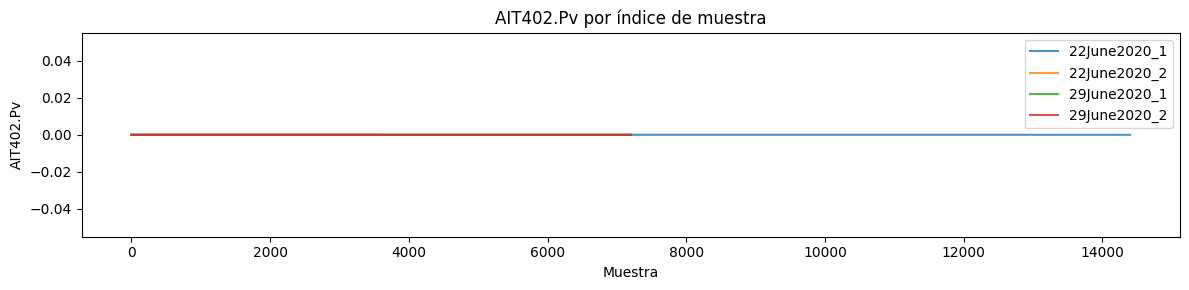

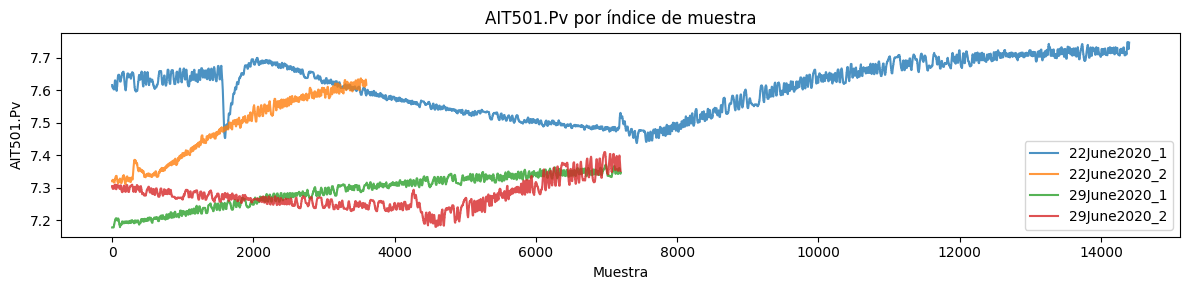

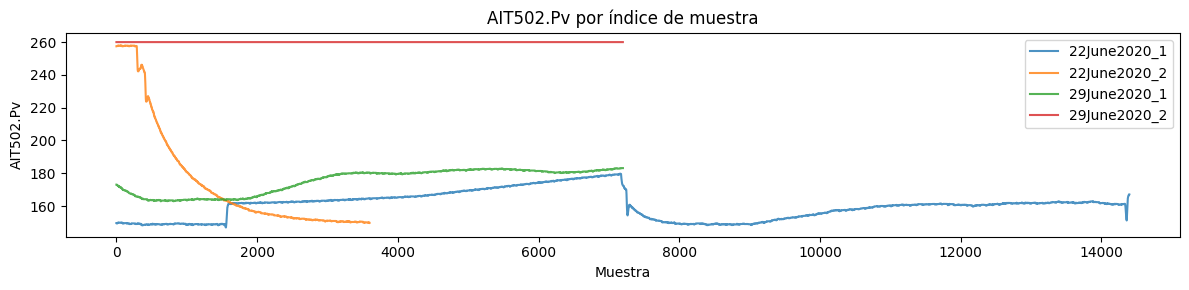

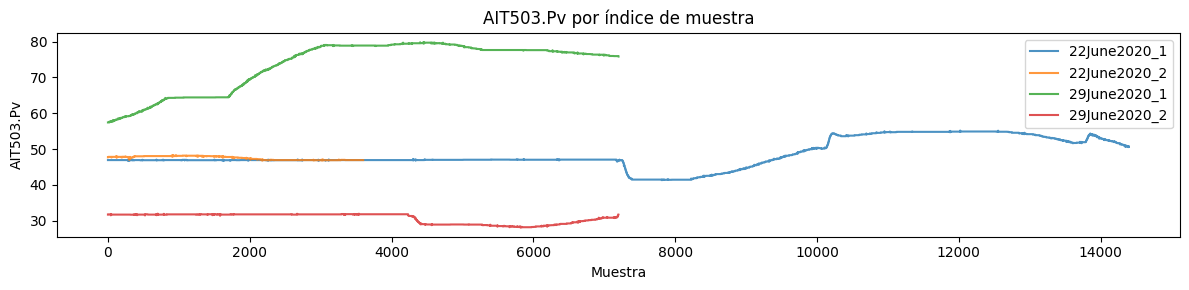

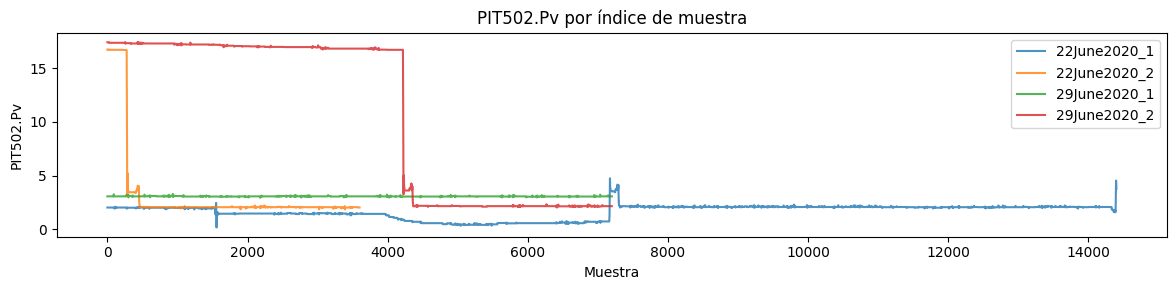

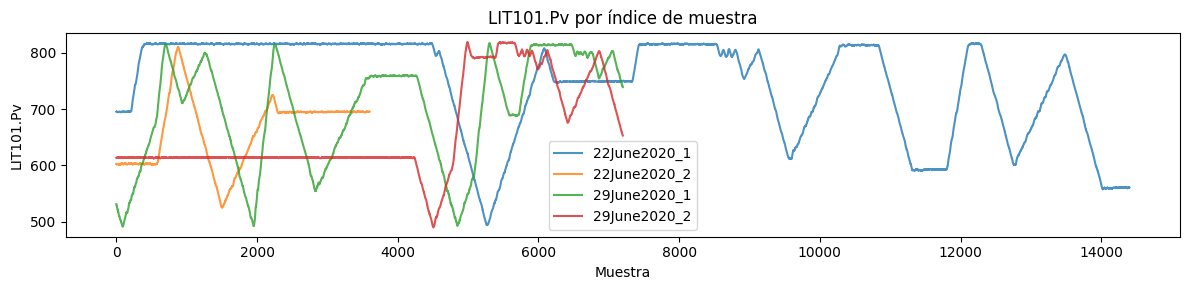

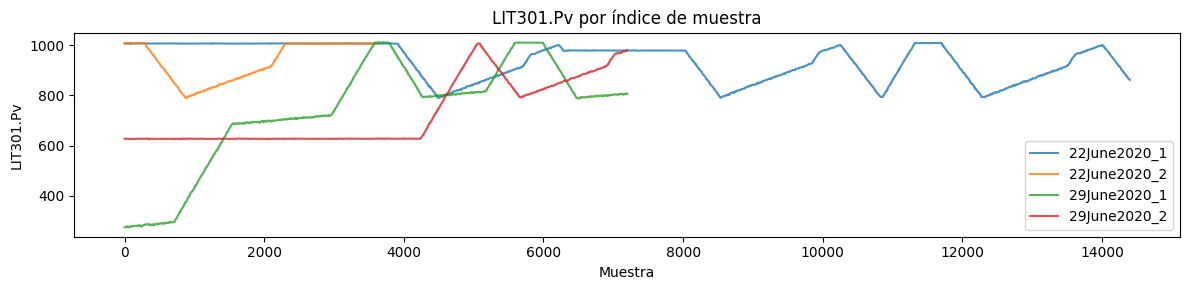

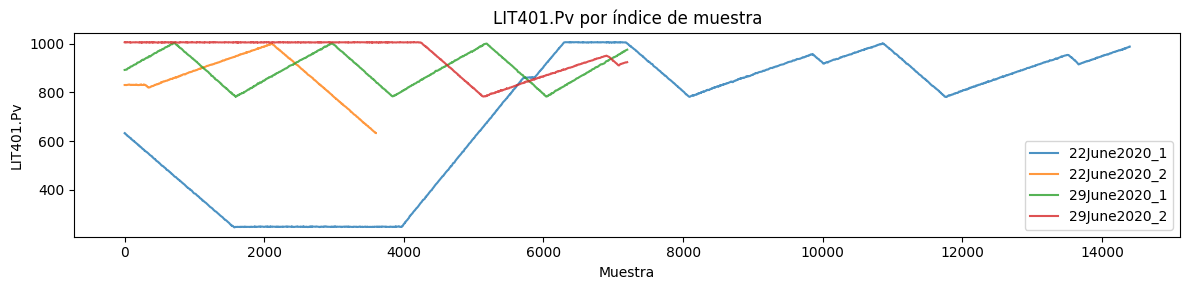

In [9]:
key_pv = [
    "AIT201.Pv", "AIT203.Pv", "AIT401.Pv", "AIT402.Pv",
    "AIT501.Pv", "AIT502.Pv", "AIT503.Pv",
    "PIT502.Pv", "LIT101.Pv", "LIT301.Pv", "LIT401.Pv"
]

for col in key_pv:
    plt.figure(figsize=(12, 3))
    for name, df in files.items():
        if col in df.columns:
            x = np.arange(len(df))
            plt.plot(x, df[col], label=name, alpha=0.8)
    plt.title(f"{col} por índice de muestra")
    plt.xlabel("Muestra")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Perfilamiento por columna

In [10]:
profile_rows = []

for col in feature_cols:
    col_type = "continuous" if col in continuous_cols else "discrete"
    values = pd.concat([df[col] for df in files.values()], axis=0)

    profile_rows.append({
        "feature": col,
        "type": col_type,
        "n_unique": values.nunique(dropna=True),
        "missing": values.isna().sum(),
        "is_constant": values.nunique(dropna=True) <= 1,
        "min": values.min() if col_type == "continuous" else None,
        "max": values.max() if col_type == "continuous" else None,
        "mean": values.mean() if col_type == "continuous" else None,
        "std": values.std() if col_type == "continuous" else None
    })

profile_df = pd.DataFrame(profile_rows).sort_values(["type", "feature"])
profile_df

,feature,type,n_unique,missing,is_constant,min,max,mean,std
0,AIT201.Pv,continuous,1817,1,False,6.729044,117.405792,4.538645e+01,3.333202e+01
1,AIT202.Pv,continuous,5838,1,False,6.525122,9.695784,8.194726e+00,8.985818e-01
2,AIT203.Pv,continuous,2954,1,False,13.919508,177.108429,1.379827e+02,2.993334e+01
3,AIT401.Pv,continuous,1,1,True,0.000000,0.000000,0.000000e+00,0.000000e+00
4,AIT402.Pv,continuous,1,1,True,0.000000,0.000000,0.000000e+00,0.000000e+00
5,AIT501.Pv,continuous,1369,1,False,7.177519,7.747885,7.449547e+00,1.689963e-01
6,AIT502.Pv,continuous,1282,1,False,146.936676,260.000000,1.876159e+02,4.132093e+01
7,AIT503.Pv,continuous,613,1,False,28.101768,79.851320,4.998782e+01,1.498397e+01
8,AIT504.Pv,continuous,358,1,False,0.038452,101.473984,2.353729e+00,4.103129e+00
9,DPIT301.Pv,continuous,1125,1,False,0.016006,19.191370,9.576453e+00,6.394101e+00


## Columnas constantes

In [11]:
constant_cols = profile_df.loc[profile_df["is_constant"], "feature"].tolist()
print("Columnas constantes:", constant_cols)

Columnas constantes: ['AIT401.Pv', 'AIT402.Pv', 'P102.Status', 'P202.Status', 'P204.Status', 'P206.Status', 'P302.Status', 'P402.Status', 'P403.Status', 'P404.Status', 'P502.Status']


In [12]:
for name in files:
    files[name] = files[name].drop(columns=constant_cols)

pv_cols = [c for c in pv_cols if c not in constant_cols]
status_cols = [c for c in status_cols if c not in constant_cols]
state_cols = [c for c in state_cols if c not in constant_cols]

feature_cols = pv_cols + status_cols + state_cols
continuous_cols = pv_cols
discrete_cols = status_cols + state_cols

print("Features después de eliminar constantes:", len(feature_cols))

Features después de eliminar constantes: 49


## Recorte de warm-up

In [13]:
WARMUP = 120

files = {
    name: df.iloc[WARMUP:].reset_index(drop=True)
    for name, df in files.items()
}

for name, df in files.items():
    print(name, df.shape)

22June2020_1 (14280, 50)
22June2020_2 (3480, 50)
29June2020_1 (7081, 50)
29June2020_2 (7081, 50)


## Separar timestamp y features

In [14]:
dfs = []

for name, df in files.items():
    dfs.append(df[feature_cols].copy())

print("Número de dataframes listos:", len(dfs))
print("Shape primero:", dfs[0].shape)

Número de dataframes listos: 4
Shape primero: (14280, 49)


## Partición temporal

In [15]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:train_end].copy()
    val_df   = df.iloc[train_end:val_end].copy()
    test_df  = df.iloc[val_end:].copy()

    return train_df, val_df, test_df

In [16]:
train_parts = []
val_parts = []
test_parts = []

for i, df_i in enumerate(dfs):
    train_i, val_i, test_i = temporal_split(df_i, train_ratio=0.6, val_ratio=0.2)

    train_parts.append(train_i)
    val_parts.append(val_i)
    test_parts.append(test_i)

    print(f"Archivo {i+1}: train={train_i.shape}, val={val_i.shape}, test={test_i.shape}")

train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)
val_df   = pd.concat(val_parts, axis=0).reset_index(drop=True)
test_df  = pd.concat(test_parts, axis=0).reset_index(drop=True)

print(train_df.shape, val_df.shape, test_df.shape)

Archivo 1: train=(8568, 49), val=(2856, 49), test=(2856, 49)
Archivo 2: train=(2088, 49), val=(696, 49), test=(696, 49)
Archivo 3: train=(4248, 49), val=(1416, 49), test=(1417, 49)
Archivo 4: train=(4248, 49), val=(1416, 49), test=(1417, 49)
(19152, 49) (6384, 49) (6386, 49)


## Escalado de variables

In [17]:
scaler_cont = StandardScaler()

train_cont = pd.DataFrame(
    scaler_cont.fit_transform(train_df[continuous_cols]),
    columns=continuous_cols
)

val_cont = pd.DataFrame(
    scaler_cont.transform(val_df[continuous_cols]),
    columns=continuous_cols
)

test_cont = pd.DataFrame(
    scaler_cont.transform(test_df[continuous_cols]),
    columns=continuous_cols
)

In [18]:
train_disc = train_df[discrete_cols].copy()
val_disc   = val_df[discrete_cols].copy()
test_disc  = test_df[discrete_cols].copy()

disc_max = train_disc.max().replace(0, 1)

train_disc_scaled = train_disc / disc_max
val_disc_scaled   = val_disc / disc_max
test_disc_scaled  = test_disc / disc_max

In [19]:
train_scaled = pd.concat(
    [train_cont.reset_index(drop=True), train_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

val_scaled = pd.concat(
    [val_cont.reset_index(drop=True), val_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

test_scaled = pd.concat(
    [test_cont.reset_index(drop=True), test_disc_scaled.reset_index(drop=True)],
    axis=1
)[continuous_cols + discrete_cols]

In [20]:
print("Continuous stats (train):")
print(train_scaled[continuous_cols].describe().loc[["mean", "std"]])

print("\nDiscrete stats (train):")
print(train_scaled[discrete_cols].describe().loc[["min", "max"]])

print("\nAny NaNs?")
print(train_scaled.isna().sum().sum())

Continuous stats (train):
         AIT201.Pv     AIT202.Pv     AIT203.Pv     AIT501.Pv     AIT502.Pv  \
mean -4.748824e-17 -1.567112e-15  1.234694e-15 -5.698588e-15 -4.748824e-17   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

         AIT503.Pv     AIT504.Pv    DPIT301.Pv     FIT101.Pv     FIT201.Pv  \
mean  2.374412e-17 -5.936030e-17 -1.068485e-16  2.374412e-17  9.497647e-17   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

      ...     FIT502.Pv     FIT503.Pv     FIT504.Pv     FIT601.Pv  \
mean  ... -7.123235e-17  5.936030e-17 -3.710018e-18 -2.968015e-18   
std   ...  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

         LIT101.Pv     LIT301.Pv     LIT401.Pv     PIT501.Pv     PIT502.Pv  \
mean -1.424647e-16 -9.497647e-17  3.799059e-16 -2.136971e-16 -2.374412e-16   
std   1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00  1.000026e+00   

      PIT503.Pv  
mean   0.000000  
std    1.000026  

[2 row

## Crear ventanas temporales

In [21]:
def create_windows(data, window_size=60, stride=5):
    windows = []
    for i in range(0, len(data) - window_size + 1, stride):
        windows.append(data[i:i + window_size])
    return np.array(windows)

In [22]:
L = 60
stride = 5

train_windows = create_windows(train_scaled.values, window_size=L, stride=stride)
val_windows   = create_windows(val_scaled.values, window_size=L, stride=stride)
test_windows  = create_windows(test_scaled.values, window_size=L, stride=stride)

print("Train windows:", train_windows.shape)
print("Val windows:", val_windows.shape)
print("Test windows:", test_windows.shape)

Train windows: (3819, 60, 49)
Val windows: (1265, 60, 49)
Test windows: (1266, 60, 49)


## Tensores y loaders

In [23]:
X_train = train_windows
X_val   = val_windows
X_test  = test_windows

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (3819, 60, 49)
X_val: (1265, 60, 49)
X_test: (1266, 60, 49)


In [24]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
val_dataset   = TensorDataset(X_val_tensor)
test_dataset  = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

## Modelo LSTM Autoencoder

In [25]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, seq_len, embedding_dim=64):
        super(LSTMAutoencoder, self).__init__()

        self.n_features = n_features
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim

        self.encoder = nn.LSTM(
            input_size=n_features,
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        self.encoder_fc = nn.Linear(128, embedding_dim)

        self.decoder_fc = nn.Linear(embedding_dim, 128)

        self.decoder = nn.LSTM(
            input_size=128,
            hidden_size=n_features,
            num_layers=1,
            batch_first=True
        )

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)                  # hidden: (1, batch, 128)
        hidden = hidden[-1]                               # (batch, 128)
        z = self.encoder_fc(hidden)                       # (batch, embedding_dim)

        decoded = self.decoder_fc(z)                      # (batch, 128)
        decoded = decoded.unsqueeze(1).repeat(1, self.seq_len, 1)  # (batch, seq_len, 128)

        x_hat, _ = self.decoder(decoded)                  # (batch, seq_len, n_features)
        return x_hat

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_features = X_train.shape[2]
seq_len = X_train.shape[1]

model = LSTMAutoencoder(
    n_features=n_features,
    seq_len=seq_len,
    embedding_dim=64
).to(device)

print("Device:", device)
print("n_features:", n_features)
print("seq_len:", seq_len)

Device: cpu
n_features: 49
seq_len: 60


## Función de perdida y optimizador

In [27]:
criterion = nn.L1Loss()   # MAE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 30
loss_history = []
val_loss_history = []

## Entrenamiento

In [28]:
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        x = batch[0].to(device)

        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    loss_history.append(epoch_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            x_val_batch = batch[0].to(device)
            x_val_hat = model(x_val_batch)
            val_loss = criterion(x_val_hat, x_val_batch)
            total_val_loss += val_loss.item()

    epoch_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(epoch_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_loss:.6f} - Val Loss: {epoch_val_loss:.6f}")

Epoch [1/30] - Train Loss: 0.636330 - Val Loss: 0.550537
Epoch [2/30] - Train Loss: 0.397536 - Val Loss: 0.352682
Epoch [3/30] - Train Loss: 0.251242 - Val Loss: 0.287335
Epoch [4/30] - Train Loss: 0.198810 - Val Loss: 0.269326
Epoch [5/30] - Train Loss: 0.178272 - Val Loss: 0.261259
Epoch [6/30] - Train Loss: 0.164399 - Val Loss: 0.253922
Epoch [7/30] - Train Loss: 0.153578 - Val Loss: 0.245923
Epoch [8/30] - Train Loss: 0.147591 - Val Loss: 0.243548
Epoch [9/30] - Train Loss: 0.142261 - Val Loss: 0.236142
Epoch [10/30] - Train Loss: 0.136388 - Val Loss: 0.231746
Epoch [11/30] - Train Loss: 0.133058 - Val Loss: 0.229248
Epoch [12/30] - Train Loss: 0.129620 - Val Loss: 0.228085
Epoch [13/30] - Train Loss: 0.126805 - Val Loss: 0.225450
Epoch [14/30] - Train Loss: 0.123859 - Val Loss: 0.224966
Epoch [15/30] - Train Loss: 0.121618 - Val Loss: 0.223214
Epoch [16/30] - Train Loss: 0.120154 - Val Loss: 0.221731
Epoch [17/30] - Train Loss: 0.118718 - Val Loss: 0.223183
Epoch [18/30] - Train L

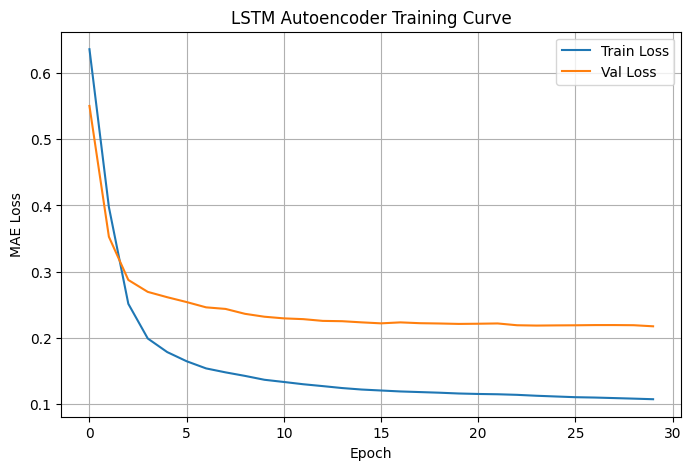

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE Loss")
plt.title("LSTM Autoencoder Training Curve")
plt.grid(True)
plt.legend()
plt.show()

## Errores de reconstrucción

In [30]:
model.eval()

with torch.no_grad():
    x_val = X_val_tensor.to(device)
    x_val_hat = model(x_val)

    val_error = torch.mean(torch.abs(x_val - x_val_hat), dim=(1, 2))
    val_reconstruction_errors = val_error.cpu().numpy()

print("Validation MAE errors shape:", val_reconstruction_errors.shape)
print("Mean:", val_reconstruction_errors.mean())
print("Std:", val_reconstruction_errors.std())

Validation MAE errors shape: (1265,)
Mean: 0.21614544
Std: 0.10194592


In [31]:
with torch.no_grad():
    x_test = X_test_tensor.to(device)
    x_test_hat = model(x_test)

    test_error = torch.mean(torch.abs(x_test - x_test_hat), dim=(1, 2))
    test_reconstruction_errors = test_error.cpu().numpy()

print("Test MAE errors shape:", test_reconstruction_errors.shape)
print("Mean:", test_reconstruction_errors.mean())
print("Std:", test_reconstruction_errors.std())

Test MAE errors shape: (1266,)
Mean: 0.20827287
Std: 0.08364092


## Histograma de errores

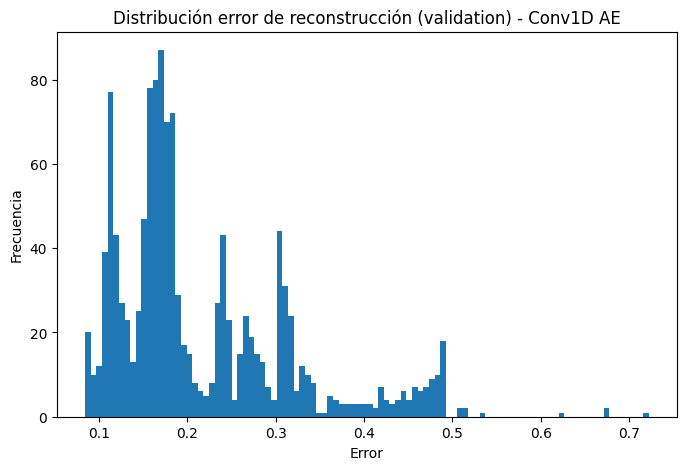

In [32]:
plt.figure(figsize=(8,5))
plt.hist(val_reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción (validation) - Conv1D AE")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

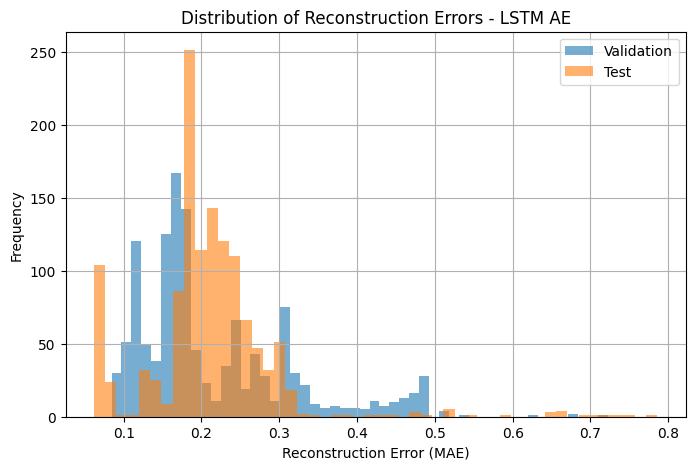

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(val_reconstruction_errors, bins=50, alpha=0.6, label="Validation")
plt.hist(test_reconstruction_errors, bins=50, alpha=0.6, label="Test")
plt.xlabel("Reconstruction Error (MAE)")
plt.ylabel("Frequency")
plt.title("Distribution of Reconstruction Errors - LSTM AE")
plt.legend()
plt.grid(True)
plt.show()

## Umbrales

In [34]:
percentiles = [90, 95, 97.5, 99, 99.5]

tau_dict = {
    p: np.percentile(val_reconstruction_errors, p)
    for p in percentiles
}

tau_df = pd.DataFrame({
    "percentile": list(tau_dict.keys()),
    "tau": list(tau_dict.values())
})

tau_df

,percentile,tau
0,90.0,0.343392
1,95.0,0.456889
2,97.5,0.483795
3,99.0,0.490356
4,99.5,0.512747


In [35]:
far_rows = []

for p, tau in tau_dict.items():
    far_val = np.mean(val_reconstruction_errors > tau)
    far_test = np.mean(test_reconstruction_errors > tau)

    far_rows.append({
        "percentile": p,
        "tau": tau,
        "FAR_val": far_val,
        "FAR_test": far_test,
        "FAR_val_pct": round(far_val * 100, 2),
        "FAR_test_pct": round(far_test * 100, 2),
    })

far_df = pd.DataFrame(far_rows)
far_df

,percentile,tau,FAR_val,FAR_test,FAR_val_pct,FAR_test_pct
0,90.0,0.343392,0.100395,0.023697,10.04,2.37
1,95.0,0.456889,0.050593,0.018957,5.06,1.90
2,97.5,0.483795,0.025296,0.016588,2.53,1.66
3,99.0,0.490356,0.010277,0.016588,1.03,1.66
4,99.5,0.512747,0.005534,0.015798,0.55,1.58
